In [1]:
import qutip as qt
from qutip import tensor, basis
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.optimize import curve_fit
from itertools import product
from quantum_logical.trotterization import Trotterization

In [2]:
# creating gates
from quantum_logical.gate_extender import Gate_extender, Convert_levels
dim = 2
N = 5
# creating the set of cnots (this will operate between the g and e levels)
cnot1 = qt.cnot(N=5, control=0, target=1)
cnot2 = qt.cnot(N=5, control=0, target=2)

cnot3 = qt.cnot(N=5, control=0, target=3)
cnot4 = qt.cnot(N=5, control=1, target=3)
 
cnot5 = qt.cnot(N=5, control=1, target=4)
cnot6 = qt.cnot(N=5, control=2, target=4)

# the x_gate needs to be made in a qutrit gate and will involve conversion 
x_gate = qt.Qobj([[0, 1],[1, 0]])

# hadamard gate
hada = qt.Qobj([[1/np.sqrt(2), 0, 1/np.sqrt(2)], [0, 1, 0], [1/np.sqrt(2), 0, -1/np.sqrt(2)]])

# new set of qutrit gates 
# extension of the gates into the qutrit space 
# need to make the gate extender take the individual qudit counts at every instance 
gate_extention = Gate_extender(num_qubits=1)
x_gate = gate_extention.qubit_to_qudit(gate=x_gate, from_dim=dim, to_dim=3)
gate_extention = Gate_extender(num_qubits=N)
cnot1 = gate_extention.qubit_to_qudit(gate=cnot1, from_dim=dim, to_dim=3)
cnot2 = gate_extention.qubit_to_qudit(gate=cnot2, from_dim=dim, to_dim=3)
cnot3 = gate_extention.qubit_to_qudit(gate=cnot3, from_dim=dim, to_dim=3)
cnot4 = gate_extention.qubit_to_qudit(gate=cnot4, from_dim=dim, to_dim=3)
cnot5 = gate_extention.qubit_to_qudit(gate=cnot5, from_dim=dim, to_dim=3)
cnot6 = gate_extention.qubit_to_qudit(gate=cnot6, from_dim=dim, to_dim=3)

cnots = [cnot1, cnot2, cnot3, cnot4, cnot5, cnot6]

# conversion of some of the gates into the qutrit space 
new_dim = 3
converter = Convert_levels(num_qubits=1)
x_gate = converter.level_conversion(levels=[0,2], dim=new_dim, gate=x_gate)
converter = Convert_levels(num_qubits=N)

cnots = [converter.level_conversion(levels=[1,2], dim=new_dim, gate=i) for i in cnots]

x_layer = tensor(tensor([x_gate] * 3), tensor([qt.qeye(new_dim)] * 2))
hada_layer = tensor(tensor([hada] * 3), tensor([qt.qeye(new_dim)] * 2))

C:\Users\girgi\AppData\Local\Temp\ipykernel_17424\687440663.py:6: DeprecationWarning: Importing functions/classes of the qip submodule directly from the namespace qutip is deprecated. Please import them from the submodule instead, e.g.
from qutip.qip.operations import cnot
from qutip.qip.circuit import QubitCircuit

  cnot1 = qt.cnot(N=5, control=0, target=1)
C:\Users\girgi\AppData\Local\Temp\ipykernel_17424\687440663.py:7: DeprecationWarning: Importing functions/classes of the qip submodule directly from the namespace qutip is deprecated. Please import them from the submodule instead, e.g.
from qutip.qip.operations import cnot
from qutip.qip.circuit import QubitCircuit

  cnot2 = qt.cnot(N=5, control=0, target=2)
C:\Users\girgi\AppData\Local\Temp\ipykernel_17424\687440663.py:9: DeprecationWarning: Importing functions/classes of the qip submodule directly from the namespace qutip is deprecated. Please import them from the submodule instead, e.g.
from qutip.qip.operations import cnot
fr

In [3]:
# building the expectation value calculator 
basis0 = qt.Qobj([[1],[0],[0]])
basis1 = qt.Qobj([[0],[1],[0]])
basis2 = qt.Qobj([[0],[0],[1]])
vectors_ = [basis0, basis1, basis2]
hada_vectors = vectors = [hada * i for i in vectors_]
vectors = [tensor(i,j,k) for i in vectors for j in vectors for k in vectors]
vectors2 = [tensor(i,j,k) for i in vectors_ for j in vectors_ for k in vectors_]

In [4]:
# building the correction z_gate 
correction_x = qt.Qobj([[0, 1],[1, 0]])
gate_extention = Gate_extender(num_qubits=1)
correction_x = gate_extention.qubit_to_qudit(gate=correction_x, from_dim=dim, to_dim=3)
converter = Convert_levels(num_qubits=1)
correction_x = converter.level_conversion(levels=[1,2], dim=new_dim, gate=correction_x)

In [5]:
correction_z = (hada * correction_x * hada.dag())
correction_z

Quantum object: dims = [[3], [3]], shape = (3, 3), type = oper, isherm = True
Qobj data =
[[ 1.  0.  0.]
 [ 0.  1.  0.]
 [ 0.  0. -1.]]

In [6]:
# generating parameters and creating initial state
T1 = 30
T2 = 30

dim = new_dim
trotter_dt = .005

# initializing Trotterization
trotter = Trotterization(trotter_dt=trotter_dt, T1=T1, T2=T2, dim=dim, num_qubits=N, qudit="qutrit")

In [7]:
# creating initial state
# state controls 
alpha = 0
beta = 1

# state
psi0 = tensor((alpha * basis(dim, 0) + beta * basis(dim, 2)).unit(), tensor([basis(dim, 0)] * (N-1)))
rho0 = psi0 * psi0.dag()
encoded_rho = rho_encoded = hada_layer  * cnots[0] * rho0 * cnots[0].dag() * hada_layer.dag()
rho_encoded_traced = qt.ptrace(rho_encoded, [0,1,2]) 
rho_encoded_traced # density matrix print confirmation

Quantum object: dims = [[3, 3, 3], [3, 3, 3]], shape = (27, 27), type = oper, isherm = True
Qobj data =
[[ 0.125  0.     0.125  0.     0.     0.    -0.125  0.    -0.125  0.
   0.     0.     0.     0.     0.     0.     0.     0.    -0.125  0.
  -0.125  0.     0.     0.     0.125  0.     0.125]
 [ 0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
   0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
   0.     0.     0.     0.     0.     0.     0.   ]
 [ 0.125  0.     0.125  0.     0.     0.    -0.125  0.    -0.125  0.
   0.     0.     0.     0.     0.     0.     0.     0.    -0.125  0.
  -0.125  0.     0.     0.     0.125  0.     0.125]
 [ 0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
   0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
   0.     0.     0.     0.     0.     0.     0.   ]
 [ 0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
   0.     0.     0.     0.     0.     0.     0.     0.     0.     0

In [8]:
vals = []
for vec in vectors:
    val = (vec.dag() * qt.ptrace(rho_encoded, [0,1,2]) * vec)[0][0][0]
    vals.append(val)
vals

[0j,
 0j,
 0j,
 0j,
 0j,
 0j,
 0j,
 0j,
 0j,
 0j,
 0j,
 0j,
 0j,
 0j,
 0j,
 0j,
 0j,
 0j,
 0j,
 0j,
 0j,
 0j,
 0j,
 0j,
 (0.999999999999999+0j),
 0j,
 0j]

In [9]:
cnots = [[cnots[0]], [cnots[1]], [cnots[2], cnots[4]], [cnots[3], cnots[5]]]

In [10]:
def sim_func(rho_encoded, T1, T2):
    trotter = Trotterization(trotter_dt=trotter_dt, T1=T1, T2=T2, dim=dim, num_qubits=N, qudit="qutrit")

    states = []
    no_error_states = []

    cnot_time = 1

    # rho_encoded0 = trotter.apply(rho=rho_encoded, duration=1, unitary=[tensor([qt.qeye(dim)] * N)], choice_error="yes")
    # gate_time = [cnot_time for _ in range(4)]
    gate_time = [cnot_time for _ in range(2)]

    rho_encoded = hada_layer * rho_encoded * hada_layer.dag()
    rho_encoded1 = hada_layer * encoded_rho * hada_layer.dag()
    for i in range(2,4):
        rho_evo = trotter.apply(rho=rho_encoded, duration=gate_time[i - 2], unitary=cnots[i], errors=True)
        rho_evo1 = trotter.apply(rho=rho_encoded1, duration=gate_time[i - 2], unitary=cnots[i], errors=False)
        states.extend(rho_evo)
        no_error_states.extend(rho_evo1)
        rho_encoded = rho_evo[-1]
        rho_encoded1 = rho_evo1[-1]
    rho_evo = hada_layer * rho_encoded * hada_layer.dag()
    rho_evo1 = hada_layer * rho_encoded1 * hada_layer.dag()
    states.append(rho_evo)
    no_error_states.append(rho_evo1)

    # recovery operation
    # measurement and recovery process 
    # projective measurement 
    options = [0,2]
    proj = [qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, i), qt.basis(dim, j)) * (qt.tensor(qt.basis(dim, i), qt.basis(dim, j))).dag())) for i in options for j in options]

    # measurement outcome value 
    projection_results = [(proj * states[-1]).tr() for proj in proj]

    # correction_operators
    r00 = qt.tensor([qt.qeye(dim)] * 5)
    r01 = qt.tensor(qt.qeye(dim), qt.qeye(dim), correction_z, qt.tensor([qt.qeye(dim)] * 2))
    r10 = qt.tensor(correction_z, qt.tensor([qt.qeye(dim)] * 4))
    r11 = qt.tensor(qt.qeye(dim), correction_z, qt.qeye(dim), qt.tensor([qt.qeye(dim)] * 2))
    recovery_ops = [[r00], [r01], [r10], [r11]]

    rec = [[proj[0], r00], [proj[1], r01], [proj[2], r10], [proj[3], r11]]

    import random
    # print(projection_results)

    # result = random.choices(rec, projection_results)
    # print(projection_results)
    # print(result)
    logicals = [vectors[24], vectors[20], vectors[8], vectors[-1]]
    vals = []
    for vec in logicals:
        val = (vec.dag() * qt.ptrace(states[-1], [0,1,2]) * vec)[0][0][0]
        vals.append(val)
    uncorrectable_error = 1 - np.abs(sum(vals))
    correctable_error = np.abs(sum(vals))

    detectable_error = sum([projection_results[i] for i in [0,2,3]]) # this is my metric for logical error 
    
    # imperfect measurement 
    projected_states = []
    # measurement_duration = .005
    for i in range(len(proj)):
        projection_state = proj[i] * states[-1] * proj[i].dag()
        # projected_state = trotter.apply(projection_state, duration=measurement_duration, unitary=[tensor([qt.qeye(dim)] * N)], errors=False)
        projected_states.append(projection_state)

    # recovery 
    corrected_states = []
    recovery_duration = .025
    for i in range(len(recovery_ops)):
        corrected_state = trotter.apply(projected_states[i], duration=recovery_duration, unitary=recovery_ops[i], errors=True)
        corrected_states.append(corrected_state)

    for i in range(len(corrected_state)):
        new_state = sum([projection_results[j] * corrected_states[j][i] for j in range(len(projection_results))])
        states.append(new_state)
        no_error_states.append(no_error_states[-1])

    logicals = [vectors[-1]]
    vals = []
    for vec in logicals:
        val = (vec.dag() * qt.ptrace(states[-1], [0,1,2]) * vec)[0][0][0]
        vals.append(val)
    errors_after_correction = 1 - np.abs(sum(vals))

    return errors_after_correction, states, no_error_states, detectable_error, uncorrectable_error, correctable_error

In [11]:
iterations = 300
states = []
no_error_states = []
fid = []
errors_after_corrections = []
detectable_errors = []
uncorrectable_errors = []
correctable_errors = []
phs = []
t1_list = np.linspace(.1, 120, iterations)
for i in tqdm(range(iterations)):
    errors_after_correction, state, no_error, detectable_error, uncorrectable_error, correctable_error = sim_func(rho_encoded=rho_encoded, T1=t1_list[i], T2=t1_list[i])
    states.extend(state)
    no_error_states.extend(no_error)
    # phs.append(errors_after_correction)
    errors_after_corrections.append(errors_after_correction)
    detectable_errors.append(detectable_error)
    uncorrectable_errors.append(uncorrectable_error)
    correctable_errors.append(correctable_error)

100%|██████████| 300/300 [30:56<00:00,  6.19s/it]


In [12]:
correctable_errors

[0.00035617037205829325,
 0.20302906632009374,
 0.41222990301899554,
 0.5413930767164303,
 0.6254566458749949,
 0.6839235846324101,
 0.7267768869583016,
 0.759477501043574,
 0.7852279829173874,
 0.8060204288013296,
 0.8231555499406666,
 0.8375173232117021,
 0.8497269269999068,
 0.860233368771442,
 0.8693691309982556,
 0.8773855939952463,
 0.8844763020905909,
 0.890792667933571,
 0.8964548305961771,
 0.9015593239760715,
 0.9061845975402705,
 0.9103950578312285,
 0.9142440732598224,
 0.9177762403059191,
 0.9210291131294879,
 0.9240345400450353,
 0.9268197070510529,
 0.9294079603206635,
 0.9318194606992342,
 0.9340717088142148,
 0.9361799696739759,
 0.938157618522406,
 0.9400164241886897,
 0.9417667831993968,
 0.9434179144241924,
 0.9449780207847532,
 0.9464544255359897,
 0.9478536869749964,
 0.9491816959079331,
 0.9504437583729268,
 0.9516446668090739,
 0.9527887599844982,
 0.9538799758329829,
 0.954921896243206,
 0.955917787530173,
 0.9568706336177347,
 0.9577831657261611,
 0.9586578890

In [13]:
import csv


# Writing the arrays to a CSV file
with open('multiple_arrays_parallel.csv', 'w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(errors_after_corrections)  # Save array1 as a row
    writer.writerow(detectable_errors)  # Save array2 as a row
    writer.writerow(uncorrectable_errors)  # Save array1 as a row
    writer.writerow(correctable_errors)  # Save array2 as a row

print("Multiple arrays have been saved to multiple_arrays.csv")


Multiple arrays have been saved to multiple_arrays.csv


In [14]:
import numpy as np

# Reading the arrays from the CSV file using NumPy
arrays = np.loadtxt('multiple_arrays.csv', delimiter=',')

Text(0.5, 1.0, 'Detectable errors vs Decoherence')

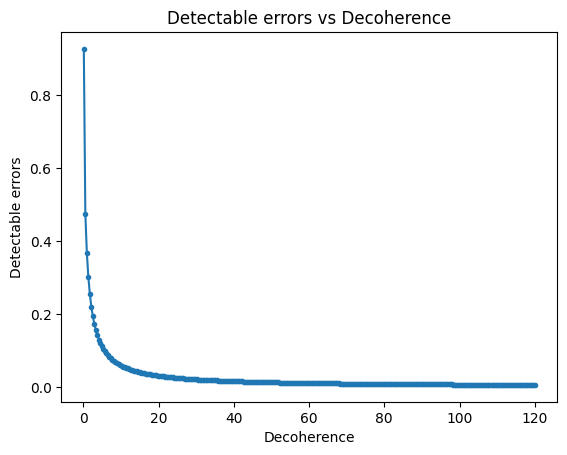

In [15]:
fig, ax = plt.subplots()
ax.plot(t1_list, detectable_errors, marker=".")
ax.set_xlabel("Decoherence")
ax.set_ylabel("Detectable errors")
ax.set_title("Detectable errors vs Decoherence")

Text(0.5, 1.0, 'Errors after correction vs Correctable errors')

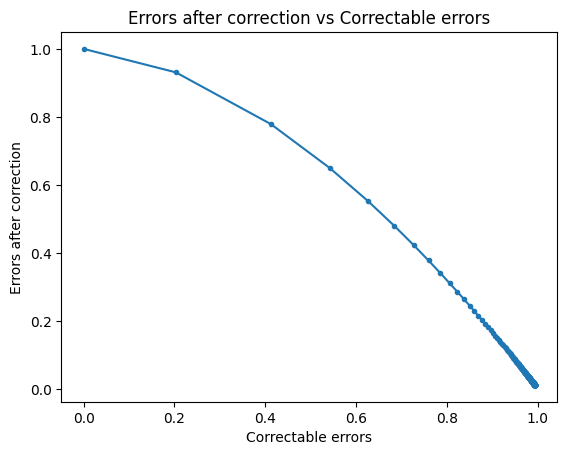

In [16]:
fig, ax = plt.subplots()
ax.plot(correctable_errors, errors_after_corrections, marker=".")
ax.set_xlabel("Correctable errors")
ax.set_ylabel("Errors after correction")
ax.set_title("Errors after correction vs Correctable errors")

Text(0.5, 1.0, 'Detectable errors vs Decoherence')

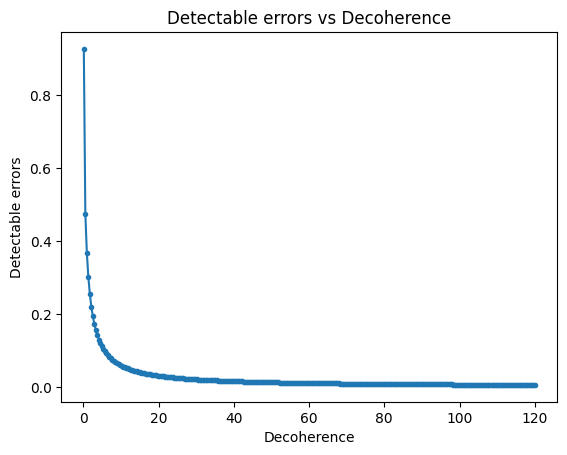

In [17]:
fig, ax = plt.subplots()
ax.plot(t1_list, detectable_errors, marker=".")
ax.set_xlabel("Decoherence")
ax.set_ylabel("Detectable errors")
ax.set_title("Detectable errors vs Decoherence")